# 1. Descargar el dataset

https://www.kaggle.com/datasets/shaunthesheep/microsoft-catsvsdogs-dataset


Creamos una carpeta editable (en `/tmp/` o `/kaggle/working/`)

Esto es necesario ya que por defecto kaggle nos descarga los datos en una carpeta en la que no tenemos parmiso para eliminar las imágenes

In [1]:
import os
import shutil
import kagglehub

# 1. Descargar el dataset
path = kagglehub.dataset_download("shaunthesheep/microsoft-catsvsdogs-dataset")
print("Path original del dataset:", path)

# 2. Crear una carpeta editable (en /tmp/ o /kaggle/working/)
if "kaggle" in path:  # Si estás en Kaggle
    editable_dir = "/kaggle/working/PetImages"
else:  # Si estás en Colab u otro entorno
    editable_dir = "/tmp/PetImages"

# 3. Copiar los archivos al directorio editable (solo si no existen)
if not os.path.exists(editable_dir):
    shutil.copytree(os.path.join(path, "PetImages"), editable_dir)

# 4. Actualizar la variable 'path' para que apunte al directorio padre de PetImages
new_path = os.path.dirname(editable_dir)  # Esto devuelve "/kaggle/working" o "/tmp"
path = new_path  # ¡Actualizamos la variable path!

print("Nuevo path editable:", path)

Path original del dataset: /kaggle/input/microsoft-catsvsdogs-dataset
Nuevo path editable: /kaggle/working


In [2]:
import os
os.listdir(path)

['PetImages']

In [3]:
import tensorflow as tf
from tensorflow import keras
from keras import layers
import matplotlib.pyplot as plt

## Filtrado de fotos incorrectas

- open(fpath, "rb") abre cada imagen en modo de "lectura binaria".
- fobj.peek(10) lee los primeros 10 bytes del archivo.
> Un archivo JPEG estándar bajo el formato JFIF debe contener la secuencia de bytes para la cadena "JFIF" en su cabecera (en los primeros 10 bytes).
- Eliminación: Si la comprobación anterior es False (es decir, not is_jfif es True), el código considera que la imagen no es un JPEG estándar y la elimina con os.remove(fpath).

Sin este paso el entrenamiento se detendría por errores de formato.

In [4]:
num_skipped = 0
num_accepted = 0
for folder_name in ("Cat", "Dog"):
    folder_path = os.path.join(path, "PetImages", folder_name)
    for fname in os.listdir(folder_path):
        fpath = os.path.join(folder_path, fname)
        try:
            fobj = open(fpath, "rb")
            is_jfif = tf.compat.as_bytes("JFIF") in fobj.peek(10)
        finally:
            fobj.close()

        if not is_jfif:
            num_skipped += 1
            # Delete corrupted image
            os.remove(fpath)
        else:
            num_accepted += 1

print(f"Imágenes eliminadas {num_skipped} y aceptadas {num_accepted}")

image_size = (180, 180)
batch_size = 32

Imágenes eliminadas 1590 y aceptadas 23412


## Generadores de datos de entrenamiento y validación
`train_ds` y `val_ds` son los conjuntos de datos de entrenamiento y validación, respectivamente. Se crean con la utilidad `image_dataset_from_directory` de Keras que busca las fotos en las carpetas y les agrega una etiqueta en función de qué carpeta haya sacado la foto.

**Ambos son generadores**, no datasets. En cada época generan un lote de 32 fotos aleatorias **sin reposición**. (hasta que las acaban y en la siguiente época vuelven a empezar)

`train_ds` (Training Dataset): Es el conjunto de datos que el modelo utiliza para aprender. En cada época, el modelo verá estas imágenes y ajustará sus pesos para minimizar el error (pérdida). `validation_split=0.2` y `subset="training"` le dicen a Keras que use el 80% de las imágenes para este conjunto.

`val_ds` (Validation Dataset): Es un conjunto de datos que el modelo no utiliza para aprender. Al final de cada época, el modelo se evalúa con este conjunto para medir su rendimiento en datos que "no ha visto antes". Esto es fundamental para saber si el modelo está generalizando bien o si está sobreajustando (memorizando) los datos de entrenamiento. `subset="validation"` le dice a Keras que use el 20% restante para este fin.

**Gracias a `seed=1337`, la división entre entrenamiento y validación será siempre la misma cada vez que ejecutes el código, lo que garantiza la reproducibilidad de los resultados.**

Found 23410 files belonging to 2 classes.
Using 18728 files for training.
Found 23410 files belonging to 2 classes.
Using 4682 files for validation.


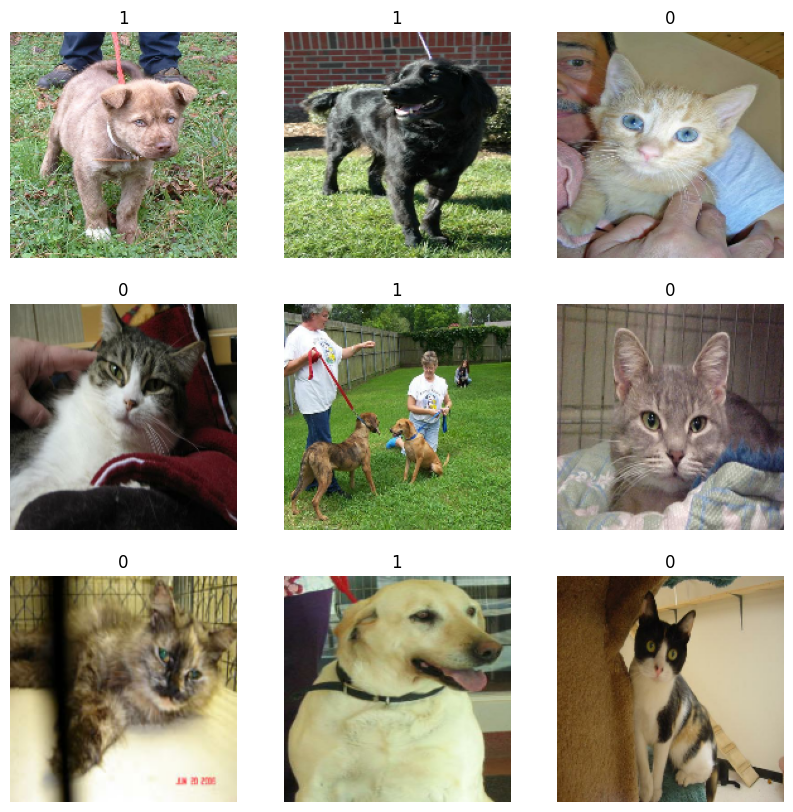

In [6]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(path, "PetImages"),
    validation_split=0.2,
    subset="training",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(path, "PetImages"),
    validation_split=0.2,
    subset="validation",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
)

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        # Podemos ver las etiquetas
        plt.title(int(labels[i]))
        plt.axis("off")

## Data augmentation

El objetivo de data_augmentation (aumento de datos) es incrementar artificialmente la diversidad del conjunto de datos de entrenamiento. Esto se hace aplicando transformaciones aleatorias a las imágenes cada vez que se le presentan al modelo.

¿Por qué se hace esto?

Para combatir el **sobreajuste** (overfitting). Si el modelo ve siempre las mismas imágenes, podría "memorizarlas" en lugar de aprender las características generales de un gato o un perro. Al mostrarle versiones ligeramente diferentes (volteadas, rotadas) en cada época, se le fuerza a aprender características más robustas y a generalizar mejor a imágenes nuevas.

In [7]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
    ]
)

Aquí vemos un ejemplo, pero no lo aplicamos ahora, sino después del escalado.

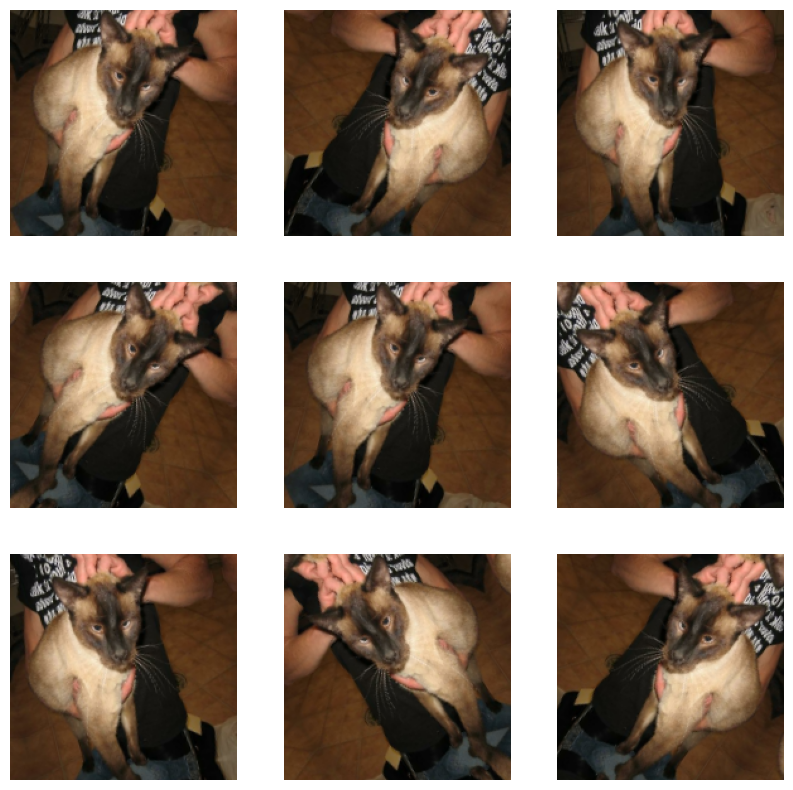

In [8]:
from matplotlib import pyplot as plt
plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
    for i in range(9):
        augmented_images = data_augmentation(images)
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_images[0].numpy().astype("uint8"))
        plt.axis("off")

## Rescaling (Reescalado)
`x = layers.Rescaling(1.0 / 255)(x)`

Esta capa multiplica cada valor de píxel de la imagen por `1.0 / 255`. Los valores de los píxeles de una imagen suelen estar en el rango de 0 a 255.

Esta operación normaliza los valores de los píxeles para que estén en el rango de 0 a 1. A las redes neuronales les resulta mucho más fácil y estable aprender cuando los valores de entrada son pequeños. Si usáramos valores de 0 a 255, los cálculos internos podrían volverse muy grandes, dificultando la convergencia del modelo (explosión del gradiente).


In [9]:
inputs = keras.Input(shape=(180,180,3))
x = data_augmentation(inputs)
x = layers.Rescaling(1./255)(x)

# Hacemos ahora el data augmentation
augmented_train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y))

## Prefetch (Precarga):
`train_ds = train_ds.prefetch(buffer_size=32)`

Esto es una optimización de rendimiento fundamental. El entrenamiento de un modelo implica dos procesos principales:
- La CPU carga los datos del disco, los decodifica, aplica el data augmentation y los prepara en lotes.
- La GPU (o TPU) toma esos lotes y realiza los cálculos de entrenamiento (el fit).

Sin prefetch, la GPU terminaría de entrenar un lote y tendría que esperar a que la CPU preparara el siguiente. Con prefetch, la CPU prepara los lotes siguientes mientras la GPU está ocupada entrenando el lote actual.

Esto crea un pipeline eficiente donde la GPU casi nunca tiene que esperar por los datos, acelerando significativamente el tiempo total de entrenamiento.

`buffer_size=32` le indica que intente mantener siempre 32 lotes listos en la memoria.

In [10]:
train_ds = train_ds.prefetch(buffer_size=32)
val_ds = val_ds.prefetch(buffer_size=32)

# Creación de la red neuronal

Arquitectura del modelo (API Funcional):

- La arquitectura utilizada es una red neuronal convolucional (CNN) profunda, inspirada en arquitecturas modernas como Xception o ResNet.

¿Por qué es así?:
- Bloque de entrada (Entry block): Recibe la imagen de (180, 180, 3). Aplica el data augmentation y el rescaling. Comienza con capas Conv2D estándar para extraer características iniciales de bajo nivel.
- Bloques intermedios (el bucle for): Aquí está la clave. Utiliza SeparableConv2D y conexiones residuales.
    - SeparableConv2D: Es una versión más eficiente de la convolución 2D. Realiza menos cálculos y tiene menos parámetros que una Conv2D normal con el mismo número de filtros, lo que permite construir redes más profundas sin un coste computacional explosivo.
    - Conexiones Residuales (layers.add([x, residual])): Esta es la característica principal de las arquitecturas tipo ResNet. Permiten que la información de una capa anterior "salte" varias capas y se sume a la salida de una capa posterior. Esto ayuda a combatir el problema del gradiente desvanecido en redes muy profundas, facilitando enormemente el entrenamiento y permitiendo que el modelo aprenda de manera más efectiva.

- Bloque de salida:
    - GlobalAveragePooling2D: Reduce drásticamente el número de parámetros antes de la capa de clasificación, aplanando cada mapa de características a un solo valor. Es una técnica de regularización muy efectiva.
    - Dropout(0.5): Apaga aleatoriamente el 50% de las neuronas durante el entrenamiento para evitar el sobreajuste.
    - Dense(units=1, activation="sigmoid"): La capa de salida. Usa 1 neurona y activación sigmoid porque es un problema de clasificación binaria (gato o perro). Sigmoid da como resultado una probabilidad entre 0 y 1.

In [12]:
def make_model(input_shape, num_classes):
    inputs = keras.Input(shape=input_shape)
    # Image augmentation block
    x = data_augmentation(inputs)

    # Entry block
    x = layers.Rescaling(1.0 / 255)(x)
    x = layers.Conv2D(32, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.Conv2D(64, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    previous_block_activation = x  # Set aside residual

    for size in [128, 256, 512, 728]:
        x = layers.Activation("relu")(x)
        x = layers.SeparableConv2D(size, 3, padding="same")(x)
        x = layers.BatchNormalization()(x)

        x = layers.Activation("relu")(x)
        x = layers.SeparableConv2D(size, 3, padding="same")(x)
        x = layers.BatchNormalization()(x)

        x = layers.MaxPooling2D(3, strides=2, padding="same")(x)

        # Project residual
        residual = layers.Conv2D(size, 1, strides=2, padding="same")(
            previous_block_activation
        )
        x = layers.add([x, residual])  # Add back residual
        previous_block_activation = x  # Set aside next residual

    x = layers.SeparableConv2D(1024, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.GlobalAveragePooling2D()(x)
    if num_classes == 2:
        activation = "sigmoid"
        units = 1
    else:
        activation = "softmax"
        units = num_classes

    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(units, activation=activation)(x)
    return keras.Model(inputs, outputs)

In [13]:
model = make_model(input_shape=image_size + (3,), num_classes=2)
keras.utils.plot_model(model, show_shapes=True)

# Entrenamiento del modelo

In [16]:
epochs = 50

callbacks = [
    keras.callbacks.ModelCheckpoint("save_at_{epoch}.h5"),
]
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
model.fit(
    train_ds, epochs=epochs, callbacks=callbacks, validation_data=val_ds,
)

Epoch 1/50
  6/586 ━━━━━━━━━━━━━━━━━━━━ 1:28:17 9s/step - accuracy: 0.9016 - loss: 0.1893

KeyboardInterrupt: 

Podemos cargar el modelo del archivo "/content/save_at_14.h5" y guardarlo en la variable model para continuar el entrenamiento o hacer predicciones.

In [15]:
model = keras.models.load_model("/content/save_at_14.h5")

In [32]:
img = keras.preprocessing.image.load_img(
    os.path.join(path, "PetImages", "Cat", "6573.jpg"), target_size=image_size
)
img_array = keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Create batch axis

predictions = model.predict(img_array)
score = predictions[0]
print(
    "This image is %.2f percent cat and %.2f percent dog."
    % (100 * (1 - score), 100 * score)
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
This image is 99.98 percent cat and 0.02 percent dog.


/tmp/ipython-input-32-3681252235.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  "This image is %.2f percent cat and %.2f percent dog."


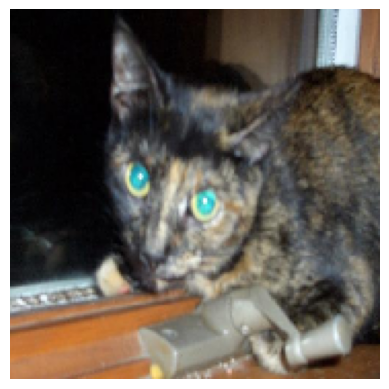

In [33]:
plt.imshow(img_array[0].numpy().astype("uint8"))
plt.axis("off")
plt.show()
